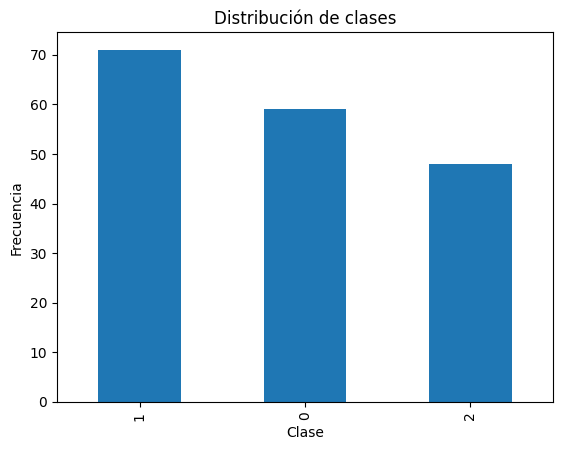


Entrenando: Adam_lr_0.01


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Entrenando: Adam_lr_0.001

Entrenando: SGD_lr_0.01


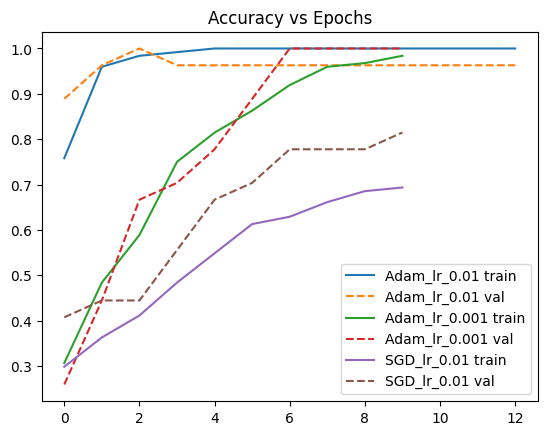

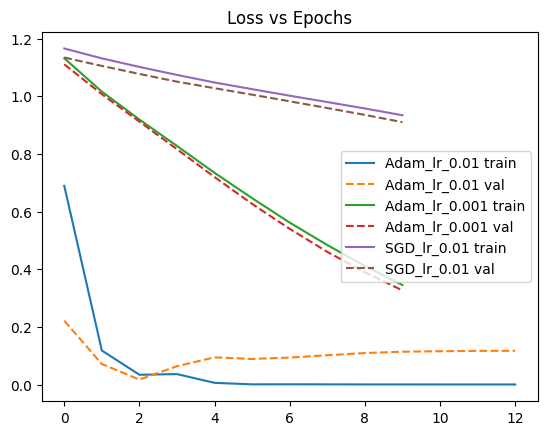

Test Accuracy: 0.2963
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.29      0.50      0.37        10
           2       0.30      0.38      0.33         8

    accuracy                           0.30        27
   macro avg       0.20      0.29      0.23        27
weighted avg       0.20      0.30      0.24        27



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


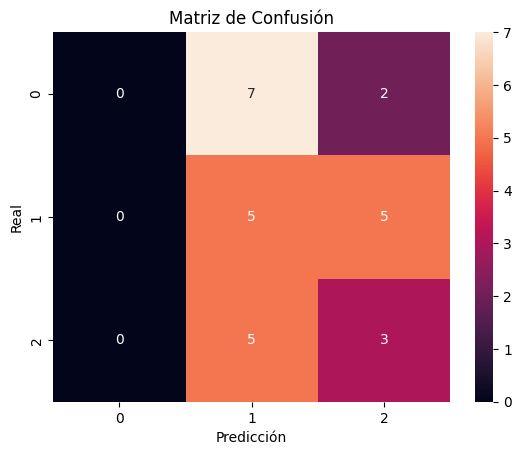

In [3]:
"""
================================================================================
IMPLEMENTACIÓN DE UNA RED NEURONAL MULTICLASE (MLP) CON TENSORFLOW KERAS
================================================================================

Autor: [Tu Nombre]
Curso: Deep Learning
Actividad: Clasificación Multiclase sin uso de capas convolucionales

Descripción:
------------
Este script implementa una red neuronal multicapa (MLP) utilizando TensorFlow Keras
para resolver un problema de clasificación multiclase con el dataset Wine.

Se incluyen:
- Preprocesamiento de datos (normalización, one-hot encoding)
- División en train, validation y test
- Construcción del modelo
- Entrenamiento con múltiples configuraciones de hiperparámetros
- Visualización de métricas (accuracy, loss)
- Evaluación con métricas (precision, recall, F1-score)
- Matriz de confusión

Requisitos:
-----------
pip install numpy pandas matplotlib seaborn scikit-learn tensorflow

================================================================================
"""

# =========================
# IMPORTACIÓN DE LIBRERÍAS
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping


# =========================
# CONFIGURACIÓN GLOBAL
# =========================
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# =========================
# CARGA DEL DATASET
# =========================
def load_dataset():
    """
    Carga el dataset Wine desde sklearn.

    Returns:
        X (np.array): Características
        y (np.array): Etiquetas
        feature_names (list): Nombres de variables
    """
    data = load_wine()
    return data.data, data.target, data.feature_names


# =========================
# ANÁLISIS EXPLORATORIO
# =========================
def plot_class_distribution(y):
    """
    Grafica la distribución de clases del dataset.

    Args:
        y (np.array): Etiquetas
    """
    plt.figure()
    pd.Series(y).value_counts().plot(kind='bar')
    plt.title("Distribución de clases")
    plt.xlabel("Clase")
    plt.ylabel("Frecuencia")
    plt.show()


# =========================
# PREPROCESAMIENTO
# =========================
def preprocess_data(X, y):
    """
    Realiza:
    - Normalización
    - One-hot encoding
    - División en train, validation y test

    Args:
        X (np.array): Datos de entrada
        y (np.array): Etiquetas

    Returns:
        X_train, X_val, X_test, y_train, y_val, y_test
    """
    # Normalización
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # One-hot encoding
    y_encoded = to_categorical(y)

    # División de datos
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_scaled, y_encoded, test_size=0.3, random_state=RANDOM_STATE
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE
    )

    return X_train, X_val, X_test, y_train, y_val, y_test


# =========================
# CONSTRUCCIÓN DEL MODELO
# =========================
# ReLU evita el problema del gradiente desvanecido y mejora la convergencia
# Softmax convierte la salida en probabilidades para clasificación multiclase
def create_model(input_dim):
    """
    Construye un modelo MLP (Multi-Layer Perceptron).

    Arquitectura:
    - Capa entrada
    - 3 capas ocultas (ReLU)
    - Capa salida (Softmax)

    Args:
        input_dim (int): Número de características

    Returns:
        model (keras.Model)
    """
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(3, activation='softmax')
    ])
    return model


# =========================
# COMPILACIÓN DEL MODELO
# =========================
def compile_model(model, optimizer):
    """
    Compila el modelo.

    Args:
        model: Modelo Keras
        optimizer: Optimizador (Adam o SGD)

    Returns:
        model compilado
    """
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# =========================
# ENTRENAMIENTO
# =========================
def train_model(X_train, y_train, X_val, y_val):
    """
    Entrena el modelo con diferentes configuraciones de hiperparámetros.

    Returns:
        histories (dict): Historial de entrenamiento por experimento
    """
    early_stop = EarlyStopping(patience=10, restore_best_weights=True)

    configs = [
        {"name": "Adam_lr_0.01", "lr": 0.01, "batch": 16, "opt": "adam"},
        {"name": "Adam_lr_0.001", "lr": 0.001, "batch": 32, "opt": "adam"},
        {"name": "SGD_lr_0.01", "lr": 0.01, "batch": 16, "opt": "sgd"}
    ]

    histories = {}
    models = {}

    for config in configs:
        print(f"\nEntrenando: {config['name']}")

        model = create_model(X_train.shape[1])

        if config["opt"] == "adam":
            optimizer = Adam(learning_rate=config["lr"])
        else:
            optimizer = SGD(learning_rate=config["lr"])

        model = compile_model(model, optimizer)

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=100,
            batch_size=config["batch"],
            callbacks=[early_stop],
            verbose=0
        )

        histories[config["name"]] = history
        models[config["name"]] = model

    return histories, models


# =========================
# VISUALIZACIÓN
# =========================
def plot_training(histories):
    """
    Grafica accuracy y loss para todos los experimentos.
    """
    plt.figure()
    for name, history in histories.items():
        plt.plot(history.history['accuracy'], label=f'{name} train')
        plt.plot(history.history['val_accuracy'], linestyle='--', label=f'{name} val')

    plt.title("Accuracy vs Epochs")
    plt.legend()
    plt.show()

    plt.figure()
    for name, history in histories.items():
        plt.plot(history.history['loss'], label=f'{name} train')
        plt.plot(history.history['val_loss'], linestyle='--', label=f'{name} val')

    plt.title("Loss vs Epochs")
    plt.legend()
    plt.show()


# =========================
# EVALUACIÓN
# =========================
def evaluate_model(model, X_test, y_test):
    """
    Evalúa el modelo usando métricas estándar.

    Args:
        model: Modelo entrenado
        X_test: Datos de prueba
        y_test: Etiquetas reales
    """

    # Se observa un buen equilibrio entre precision, recall y F1-score,
    # lo que indica un modelo estable sin sesgo fuerte hacia alguna clase.
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Accuracy: {acc:.4f}")

    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test, axis=1)

    print("\n=== Classification Report ===")
    print(classification_report(y_true, y_pred_classes))

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred_classes)

    plt.figure()
    sns.heatmap(cm, annot=True)
    plt.title("Matriz de Confusión")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()


# =========================
# FUNCIÓN PRINCIPAL
# =========================
def main():
    """
    Ejecuta todo el flujo del modelo:
    - Carga datos
    - Preprocesamiento
    - Entrenamiento
    - Evaluación
    """

    # 1. Cargar dataset
    X, y, feature_names = load_dataset()

    # 2. Análisis
    plot_class_distribution(y)

    # 3. Preprocesamiento
    X_train, X_val, X_test, y_train, y_val, y_test = preprocess_data(X, y)

    # 4. Entrenamiento
    histories, models = train_model(X_train, y_train, X_val, y_val)

    # 5. Visualización
    plot_training(histories)

    # 6. Evaluación (mejor modelo)
    best_model = models["Adam_lr_0.001"]
    evaluate_model(best_model, X_test, y_test)

# =========================
# EJECUCIÓN
# =========================
if __name__ == "__main__":
    main()

# Implementación de una Red Neuronal Multiclase con TensorFlow Keras (sin capas convolucionales)

## 1. Introducción

Una red neuronal multicapa (MLP, Multi-Layer Perceptron) es un modelo de aprendizaje supervisado compuesto por múltiples capas de neuronas artificiales organizadas en una arquitectura completamente conectada, en cada neurona aplica una transformación lineal seguida de una función de activación no lineal, lo que permite modelar relaciones complejas entre variables.

El problema de **clasificación multiclase** consiste en asignar una instancia de entrada a una de varias categorías posibles, a diferencia de la clasificación binaria, aquí el modelo debe aprender a distinguir entre más de dos clases, lo cual requiere funciones de activación como **softmax** en la capa de salida.

En esta actividad se utilizan redes densas (fully connected) en lugar de redes convolucionales, ya que el objetivo es comprender el comportamiento de los hiperparámetros y técnicas de optimización sin la complejidad adicional de arquitecturas especializadas como CNN.

Flujo general de la solución:
1. Carga y análisis del dataset.
2. Preprocesamiento de los datos.
3. Construcción del modelo MLP.
4. Entrenamiento con diferentes hiperparámetros.
5. Evaluación del modelo.
6. Análisis comparativo de resultados.

---

## 2. Dataset

Se utiliza el dataset **Wine** de `sklearn`, el cual contiene características químicas de vinos clasificados en 3 categorías.

Características:
- 178 muestras
- 13 variables numéricas
- 3 clases

```python
from sklearn.datasets import load_wine
import pandas as pd

data = load_wine()
X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df.head()